## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_psi import *
from funcoes_escoragem import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Variáveis Blend4 - Desenvolvimento

In [5]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527
'''

df_raw = pd.read_gbq(query, project_id=project_id)
df_raw

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,SERASA_CHSV5,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,344,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,202,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,729,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,509,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,97,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451912,3568827,2025-12-31,2025-12-01,440.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,411,30.0,1.0,1.0,1890.0,3836.0,NaN,0.140432,0.0,0.0
1451913,3568830,2025-12-31,2025-12-01,607.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,543,25.0,1.0,0.0,2310.0,2877.0,NaN,NaN,0.0,0.0
1451914,3568839,2025-12-31,2025-12-01,362.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,241,25.0,1.0,1.0,630.0,1370.0,NaN,0.131579,0.0,0.0
1451915,3568841,2025-12-31,2025-12-01,480.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,411,47.0,1.0,0.0,1995.0,3219.5,NaN,NaN,0.0,0.0


In [11]:
df_dev_blend4 = df_raw.copy()
df_dev_blend4["safra"] = df_dev_blend4["requested_at"].astype(str).str[:7]
df_dev_blend4 = df_dev_blend4[df_dev_blend4["safra"] <= "2025-08"]
df_dev_blend4

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356517,3076096,2025-08-31,2025-08-01,174.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,32.0,1.0,10.0,1470.0,2260.5,NaN,0.119675,0.0,0.0,2025-08
1356518,3076104,2025-08-31,2025-08-01,817.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,59.0,1.0,0.0,2677.5,11713.5,NaN,0.108987,0.0,0.0,2025-08
1356519,3076105,2025-08-31,2025-08-01,335.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,20.0,1.0,0.0,1627.5,1781.0,NaN,0.110814,0.0,0.0,2025-08
1356520,3076115,2025-08-31,2025-08-01,278.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,22.0,1.0,0.0,1680.0,1644.0,NaN,0.115226,0.0,0.0,2025-08


In [12]:
bvs = pd.to_numeric(df_dev_blend4["score_proposto__bvs"], errors="coerce")
score = pd.to_numeric(df_dev_blend4["pred_blend4_1_to_score"], errors="coerce")

conditions = [
    bvs <= 334,                         # corte customizado BVS → E
    score.between(763, 1000),           # 763 – 1000
    score.between(704, 762),            # 704 – 762
    score.between(653, 703),            # 653 – 703
    score.between(607, 652),            # 607 – 652
    score.between(562, 606),            # 562 – 606
    score.between(520, 561),            # 520 – 561
    score.between(480, 519),            # 480 – 519
    score.between(443, 479),            # 443 – 479
    score.between(408, 442),            # 408 – 442
    score.between(375, 407),            # 375 – 407
    score.between(343, 374),            # 343 – 374
    score.between(307, 342),            # 307 – 342
    score.between(0, 306),              # 0 – 306
]

choices = [
    "9.E.BVS",      # override BVS ≤ 334
    "1.A+",
    "2.A",
    "2.A",
    "3.B+",
    "3.B+",
    "4.B",
    "4.B",
    "5.C",
    "6.D+",
    "7.D",
    "7.D",
    "8.E",
    "8.E",
]

df_dev_blend4["rating_pol_blend4"] = np.select(conditions, choices, default=None)

## Distribuição Ratings - Salvar

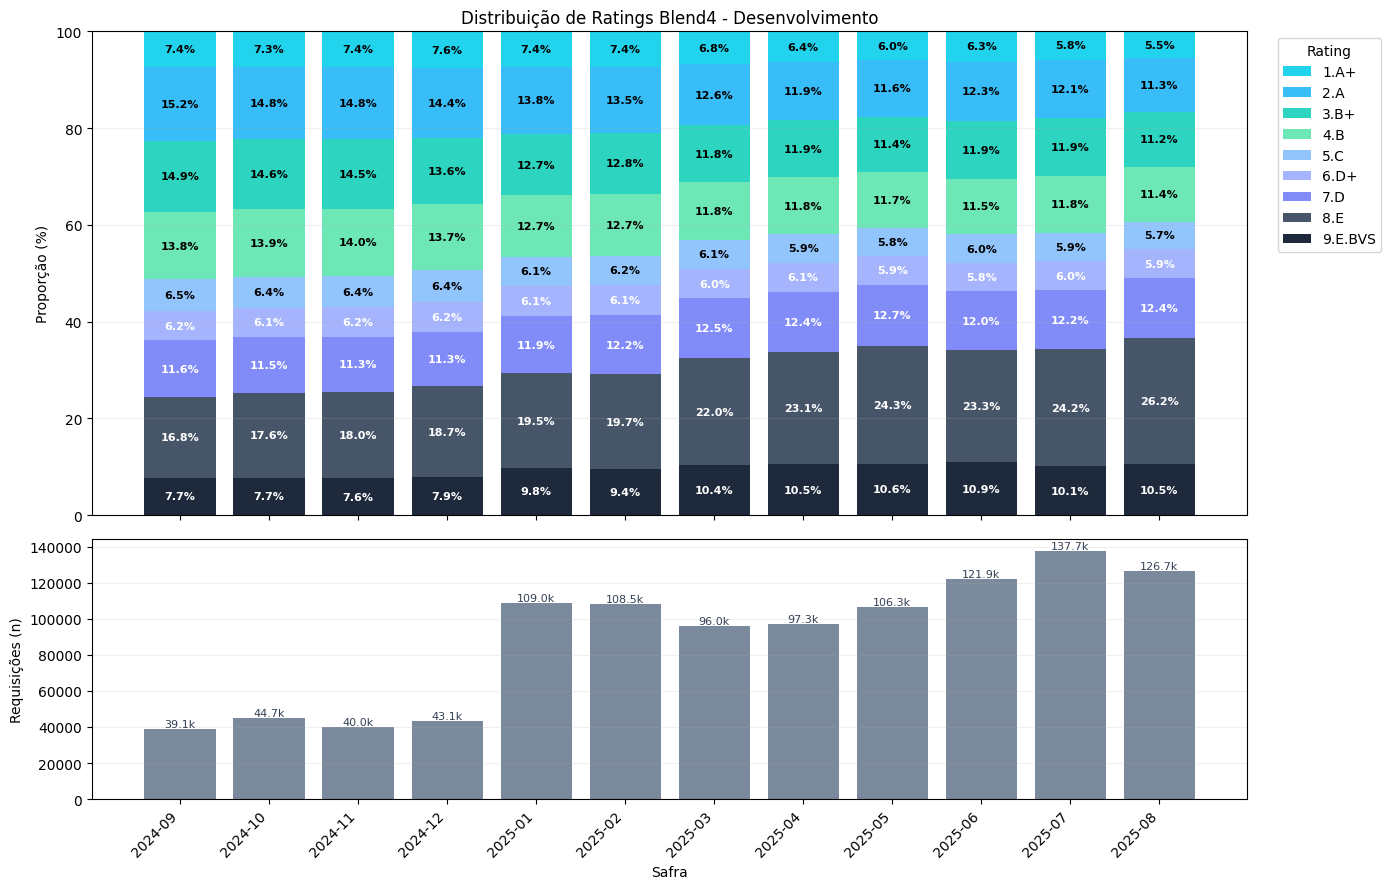

In [17]:
from funcoes_monitoramento import plot_mix_and_volume

RATING_CL_POL_ORDER = [
    "1.A+", "2.A", "3.B+", "4.B", "5.C",
    "6.D+", "7.D", "8.E", "9.E.BVS",
]

RATING_CL_POL_COLOR_MAP = {
    "1.A+": "#22D3EE", "2.A": "#38BDF8", "3.B+": "#2DD4BF",
    "4.B": "#6EE7B7", "5.C": "#93C5FD", "6.D+": "#A5B4FC",
    "7.D": "#818CF8", "8.E": "#475569", "9.E.BVS": "#1E293B",
}

RATING_CL_POL_TEXT_COLOR_MAP = {
    "1.A+": "black", "2.A": "black", "3.B+": "black",
    "4.B": "black", "5.C": "black", "6.D+": "white",
    "7.D": "white", "8.E": "white", "9.E.BVS": "white",
}

plot_df = df_dev_blend4.dropna(subset=["rating_pol_blend4", "safra"]).copy()
plot_df["safra"] = plot_df["safra"].astype(str)
safra_order = sorted(plot_df["safra"].unique())

pct_df = (
    pd.crosstab(plot_df["safra"], plot_df["rating_pol_blend4"], normalize="index")
    .mul(100)
    .reindex(index=safra_order)
    .reindex(columns=RATING_CL_POL_ORDER, fill_value=0)
)

volume = plot_df.groupby("safra").size().reindex(safra_order, fill_value=0)

plot_mix_and_volume(
    pct_df,
    volume,
    title="Distribuição de Ratings Blend4 - Desenvolvimento",
    xlabel="Safra",
    category_order=RATING_CL_POL_ORDER,
    color_map=RATING_CL_POL_COLOR_MAP,
    text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Rating",
    min_label_pct=3.0,
)
plt.show()

In [25]:
pct_df

rating_pol_blend4,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS
safra,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488


In [26]:
df = pct_df.join(pd.DataFrame(volume).rename(columns={0: "volume"}), on="safra", how="left")
df

,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS,volume
safra,,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746,39121
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185,44731
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311,40001
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281,43060
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168,109011
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361,108527
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723,96018
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915,97266
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488,106310


In [27]:
df.to_csv(ANALYTICS_DIR/"dev_rating_pol_blend4.csv")

## Restrição BVS e Preparação de Variáveis

In [ ]:
df_dev_blend4 = df_dev_blend4[df_dev_blend4["score_proposto__bvs"] > 334]
df_predict = prepare_blend4_variables(df_dev_blend4)
# df_predict = predict_blend4_1(df_predict_vars)

## Base Blend4 em Produção

In [7]:
df = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df = df[df["REGRA_BLEND_4"] == "BLEND4"].copy()
df

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,id_consulta,result_pre_analise,id_bureau,risco_cartoes,id_pessoa,protestados_outros_estados,...,SERASA_CHSV5__normalized4_1,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4
0,23327155844,4075162,2026-05-26,2026-05-26,5853589,APROVAR,1,0,NaN,N,...,-0.311953,0.05,6.0,0.561859,0.000000,-1.075775,0.551459,449.0,B,E
1,55955854800,4094024,2026-05-25,2026-05-25,5845896,APROVAR,1,0,NaN,N,...,-0.180758,-0.75,3.0,0.420780,0.000000,-0.422551,0.569824,430.0,C,D
2,6125558959,4098335,2026-05-29,2026-05-29,5874250,APROVAR,1,0,NaN,N,...,1.379009,0.25,0.0,-0.386170,0.000000,-0.132721,0.117847,882.0,A,A
3,6437719486,4111351,2026-05-25,2026-05-25,5846225,APROVAR,1,0,NaN,N,...,0.413994,0.30,0.0,-0.193922,0.000000,-0.553292,0.250161,750.0,A,A
4,8227836810,4131057,2026-06-08,2026-06-08,5910546,APROVAR,1,0,NaN,N,...,0.198251,1.45,0.0,-0.007109,-0.040739,-0.312551,0.426500,573.0,A,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206445,42009122879,4276978,2026-06-19,2026-06-19,5977752,REPROVAR,1,0,NaN,N,...,1.215743,-0.30,0.0,-0.874238,0.000000,-0.705170,0.108602,891.0,A,A
206447,10367694964,4277167,2026-06-20,2026-06-20,5978012,REPROVAR,1,0,NaN,N,...,-0.320700,-0.75,0.0,1.055686,0.000000,0.183532,0.623164,377.0,D,C
206448,2293324800,4277417,2026-06-20,2026-06-20,5978311,DERIVAR,1,0,NaN,N,...,0.000000,0.00,0.0,0.000000,0.000000,-0.128057,0.566017,434.0,C,NaN
206450,4592120604,4278015,2026-06-20,2026-06-20,5979027,REPROVAR,1,0,NaN,N,...,0.597668,-0.45,1.0,1.065713,0.000000,1.588008,0.303104,697.0,A,B


In [8]:
df[df["income"] <= 479.5]

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,id_consulta,result_pre_analise,id_bureau,risco_cartoes,id_pessoa,protestados_outros_estados,...,SERASA_CHSV5__normalized4_1,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4
23,916696006,4168727,2026-05-25,2026-05-25,5843500,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.032180,0.914387,0.649910,350.0,D,NaN
29,44920419821,4169070,2026-05-25,2026-05-25,5843912,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.658138,0.578728,421.0,C,NaN
30,9387377407,4169075,2026-05-25,2026-05-25,5843920,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.012982,1.286981,0.637739,362.0,D,NaN
38,48388510819,4170336,2026-05-25,2026-05-25,5845454,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.392046,0.559116,441.0,C,NaN
46,10444551956,4171178,2026-05-25,2026-05-25,5846523,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.387841,0.529686,470.0,B,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206417,12865969983,4274193,2026-06-19,2026-06-19,5974201,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.212153,1.696611,0.714884,285.0,E,NaN
206425,23141558825,4275292,2026-06-19,2026-06-19,5975577,APROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,0.320622,0.615861,384.0,D,NaN
206436,36285785821,4276315,2026-06-19,2026-06-19,5976869,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.448669,0.575582,424.0,C,NaN
206442,8966643680,4276679,2026-06-19,2026-06-19,5977471,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.312551,0.604701,395.0,D,NaN


In [9]:
df[df["income"] == 0]

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,id_consulta,result_pre_analise,id_bureau,risco_cartoes,id_pessoa,protestados_outros_estados,...,SERASA_CHSV5__normalized4_1,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4
23,916696006,4168727,2026-05-25,2026-05-25,5843500,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.032180,0.914387,0.649910,350.0,D,NaN
29,44920419821,4169070,2026-05-25,2026-05-25,5843912,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.658138,0.578728,421.0,C,NaN
30,9387377407,4169075,2026-05-25,2026-05-25,5843920,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.012982,1.286981,0.637739,362.0,D,NaN
38,48388510819,4170336,2026-05-25,2026-05-25,5845454,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.392046,0.559116,441.0,C,NaN
46,10444551956,4171178,2026-05-25,2026-05-25,5846523,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.387841,0.529686,470.0,B,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206417,12865969983,4274193,2026-06-19,2026-06-19,5974201,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.212153,1.696611,0.714884,285.0,E,NaN
206425,23141558825,4275292,2026-06-19,2026-06-19,5975577,APROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,0.320622,0.615861,384.0,D,NaN
206436,36285785821,4276315,2026-06-19,2026-06-19,5976869,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.448669,0.575582,424.0,C,NaN
206442,8966643680,4276679,2026-06-19,2026-06-19,5977471,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.312551,0.604701,395.0,D,NaN


In [10]:
100*(25140/192697)

13.046388890330416

In [11]:
df[df["income"] == 0.0]

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,id_consulta,result_pre_analise,id_bureau,risco_cartoes,id_pessoa,protestados_outros_estados,...,SERASA_CHSV5__normalized4_1,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4
23,916696006,4168727,2026-05-25,2026-05-25,5843500,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.032180,0.914387,0.649910,350.0,D,NaN
29,44920419821,4169070,2026-05-25,2026-05-25,5843912,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.658138,0.578728,421.0,C,NaN
30,9387377407,4169075,2026-05-25,2026-05-25,5843920,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.012982,1.286981,0.637739,362.0,D,NaN
38,48388510819,4170336,2026-05-25,2026-05-25,5845454,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.392046,0.559116,441.0,C,NaN
46,10444551956,4171178,2026-05-25,2026-05-25,5846523,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.387841,0.529686,470.0,B,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206417,12865969983,4274193,2026-06-19,2026-06-19,5974201,REPROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.212153,1.696611,0.714884,285.0,E,NaN
206425,23141558825,4275292,2026-06-19,2026-06-19,5975577,APROVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,0.320622,0.615861,384.0,D,NaN
206436,36285785821,4276315,2026-06-19,2026-06-19,5976869,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-1.448669,0.575582,424.0,C,NaN
206442,8966643680,4276679,2026-06-19,2026-06-19,5977471,DERIVAR,1,0,NaN,N,...,0.0,0.0,0.0,0.0,0.000000,-0.312551,0.604701,395.0,D,NaN


In [12]:
df_raw[df_raw["age"] < 18]["age"].value_counts()

age
0.0     115
17.0     27
16.0      4
15.0      1
Name: count, dtype: int64

In [13]:
df[df["age"] < 18]["age"].value_counts()

age
0.0    94
Name: count, dtype: int64

## PSI de Variáveis: Treino/Teste e OOT

In [14]:
model_vars = [
    "score_proposto__bvs__normalized4_1",
    "SERASA_CHSV5__normalized4_1",
    "age__normalized4_1",
    "property_type",
    "qtde_restricoes__consulta_realizada__normalized4_1",
    "income_commitment__normalized4_1",
    "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1",
    "city_pc4_mais_100_contratos__pc_categorias__normalized4_1",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "pred_blend4_1_to_score",
]

In [15]:
from funcoes_psi import (
    calculate_development_psi_baselines,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

train_mask = df_dev_blend4["FLAG_TESTE"] == 0
test_mask = df_dev_blend4["FLAG_TESTE"] == 1
oot_mask = df_dev_blend4["FLAG_OOT"] == 1

psi_baseline_long, psi_reference_artifact = calculate_development_psi_baselines(
    df=df_predict,
    variables=model_vars,
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
4,city_pc4_mais_100_contratos__pc_categorias__no...,0.054831,0.000085
9,pred_blend4_1_to_score,0.023761,0.000040
11,qtde_restricoes__consulta_realizada__normalize...,0.023595,0.000028
0,SERASA_CHSV5__normalized4_1,0.020552,0.000130
12,score_proposto__bvs__normalized4_1,0.010233,0.000116
2,agency_pc4_mais_100_contratos__pc_categorias__...,0.005090,0.000026
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age__normalized4_1,0.001148,0.000071
8,income_commitment__normalized4_1,0.000870,0.000048


## Salvar Artefatos

In [16]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact = calculate_development_psi_baselines_final(
    df=df_predict,
    variables=model_vars,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
4,city_pc4_mais_100_contratos__pc_categorias__no...,0.054831,0.000085
9,pred_blend4_1_to_score,0.023761,0.000040
11,qtde_restricoes__consulta_realizada__normalize...,0.023595,0.000028
0,SERASA_CHSV5__normalized4_1,0.020552,0.000130
12,score_proposto__bvs__normalized4_1,0.010233,0.000116
2,agency_pc4_mais_100_contratos__pc_categorias__...,0.005090,0.000026
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age__normalized4_1,0.001148,0.000071
8,income_commitment__normalized4_1,0.000870,0.000048


In [17]:
# Save single artifact + baseline table
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_psi_reference.pkl"
PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

save_psi_reference(psi_reference_artifact, PSI_REFERENCE_PATH)
psi_baseline_ref.to_csv(PSI_BASELINE_PATH, index=False)

print(f"Saved artifact: {PSI_REFERENCE_PATH}")
print(f"Saved baseline: {PSI_BASELINE_PATH}")

Saved artifact: data/analytics/blend4_psi_reference.pkl
Saved baseline: data/analytics/blend4_psi_baseline_ref.csv


## Avaliação PSI-Produção

In [18]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)
psi_df

,variable,comparison,psi,status,n_actual
0,SERASA_CHSV5__normalized4_1,production_vs_train,0.437692,unstable,192697
1,score_proposto__bvs__normalized4_1,production_vs_train,0.369647,unstable,192697
2,pred_blend4_1_to_score,production_vs_train,0.284656,unstable,192697
3,income_commitment__normalized4_1,production_vs_train,0.130063,moderate,192697
4,age__normalized4_1,production_vs_train,0.099583,stable,192697
5,city_pc4_mais_100_contratos__pc_categorias__no...,production_vs_train,0.058854,stable,192697
6,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.003308,stable,192697
7,qtde_restricoes__consulta_realizada__normalize...,production_vs_train,0.000662,stable,192697
8,agency_pc4_mais_100_contratos__pc_categorias__...,production_vs_train,0.000311,stable,192697
9,property_type,production_vs_train,0.000301,stable,192697


## Artefato Exclusivo BVS

In [ ]:
df_bvs = df_raw.copy()
df_bvs["SCORE_BVS"] = df_bvs["score_proposto__bvs"]

In [44]:
train_mask = df_bvs["FLAG_TESTE"] == 0
test_mask = df_bvs["FLAG_TESTE"] == 1
oot_mask = df_bvs["FLAG_OOT"] == 1

psi_baseline_long_bvs, psi_reference_artifact_bvs = calculate_development_psi_baselines(
    df=df_bvs,
    variables=["score_proposto__bvs"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "bvs_score",
        "variable": "score_proposto__bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs,0.005622,0.000099


In [47]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact_bvs = calculate_development_psi_baselines_final(
    df=df_bvs,
    variables=["SCORE_BVS"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_score_bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "BVS_Score_Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs,0.005622,0.000099


In [48]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
save_psi_reference(psi_reference_artifact_bvs, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

Saved artifact: data/analytics/blend4_bvs_score_psi_reference.pkl


## Artefato Renda e Aluguel

In [22]:
train_mask = df_raw["FLAG_TESTE"] == 0
test_mask = df_raw["FLAG_TESTE"] == 1
oot_mask = df_raw["FLAG_OOT"] == 1

psi_baseline_long_raw, psi_reference_artifact_raw = calculate_development_psi_baselines(
    df=df_raw,
    variables=["rental_value", "income"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,income,0.001696,0.000081
1,rental_value,0.007860,0.000068


In [23]:
psi_reference_artifact_raw = calculate_development_psi_baselines_final(
    df=df_raw,
    variables=["rental_value", "income"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,income,0.001696,0.000081
1,rental_value,0.007860,0.000068


In [24]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df,
    artifact=psi_reference_artifact_raw,
    comparison_label="production_vs_development",
    variables=["rental_value", "income"],
)
psi_df

,variable,comparison,psi,status,n_actual
0,rental_value,production_vs_development,0.065310,stable,192693
1,income,production_vs_development,0.009183,stable,192697


In [36]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
save_psi_reference(psi_reference_artifact_raw, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

Saved artifact: data/analytics/psi_income_rental_reference.pkl


In [25]:
psi_reference_artifact_raw["variables"]["rental_value"]


{'type': 'quantile',
 'edges': [1.05,
  840.0,
  1050.0,
  1207.5,
  1365.0,
  1575.0,
  1732.5,
  2034.375,
  2493.75,
  3255.0,
  20895.0],
 'bin_labels': ['(1.050000, 840.000000]',
  '(840.000000, 1050.000000]',
  '(1050.000000, 1207.500000]',
  '(1207.500000, 1365.000000]',
  '(1365.000000, 1575.000000]',
  '(1575.000000, 1732.500000]',
  '(1732.500000, 2034.375000]',
  '(2034.375000, 2493.750000]',
  '(2493.750000, 3255.000000]',
  '(3255.000000, 20895.000000]'],
 'expected_counts': {'(1.050000, 840.000000]': 147934,
  '(840.000000, 1050.000000]': 196774,
  '(1050.000000, 1207.500000]': 94721,
  '(1207.500000, 1365.000000]': 165900,
  '(1365.000000, 1575.000000]': 183804,
  '(1575.000000, 1732.500000]': 84582,
  '(1732.500000, 2034.375000]': 142693,
  '(2034.375000, 2493.750000]': 145252,
  '(2493.750000, 3255.000000]': 145842,
  '(3255.000000, 20895.000000]': 144415}}

In [26]:
psi_reference_artifact_raw["variables"]["income"]

{'type': 'quantile',
 'edges': [479.5,
  1575.5,
  1849.5,
  2192.0,
  2740.0,
  3699.0,
  4452.5,
  5480.0,
  7740.5,
  12946.5,
  184881.5],
 'bin_labels': ['(479.500000, 1575.500000]',
  '(1575.500000, 1849.500000]',
  '(1849.500000, 2192.000000]',
  '(2192.000000, 2740.000000]',
  '(2740.000000, 3699.000000]',
  '(3699.000000, 4452.500000]',
  '(4452.500000, 5480.000000]',
  '(5480.000000, 7740.500000]',
  '(7740.500000, 12946.500000]',
  '(12946.500000, 184881.500000]'],
 'expected_counts': {'(479.500000, 1575.500000]': 172480,
  '(1575.500000, 1849.500000]': 136336,
  '(1849.500000, 2192.000000]': 131577,
  '(2192.000000, 2740.000000]': 140418,
  '(2740.000000, 3699.000000]': 149364,
  '(3699.000000, 4452.500000]': 143706,
  '(4452.500000, 5480.000000]': 143928,
  '(5480.000000, 7740.500000]': 146588,
  '(7740.500000, 12946.500000]': 142796,
  '(12946.500000, 184881.500000]': 144724}}

## Avaliar Renda e Aluguel em valores Brutos

In [27]:
df_predict[["rental_value", "income", "income_commitment", "age"]].describe()

,rental_value,income,income_commitment,age
count,964559.000000,964559.000000,964559.000000,964559.000000
mean,1924.498164,7310.812823,0.536164,37.758577
std,1449.515413,13050.017738,0.481497,14.268551
min,1.050000,479.500000,0.000028,0.000000
25%,1103.865000,2055.000000,0.236096,26.000000
50%,1575.000000,3836.000000,0.422854,35.000000
75%,2205.000000,6644.500000,0.696749,47.000000
max,20895.000000,184881.500000,15.671341,89.000000


In [28]:
df[["rental_value", "income", "income_commitment", "age"]].describe()

,rental_value,income,income_commitment,age
count,1.926930e+05,192697.000000,192697.000000,192697.000000
mean,2.533899e+03,6555.200645,0.738519,37.622418
std,6.359068e+04,14575.245821,12.187928,13.791065
min,1.000000e+00,0.000000,0.000124,0.000000
25%,1.200000e+03,1644.000000,0.265428,28.000000
50%,1.600000e+03,2877.000000,0.429945,34.000000
75%,2.310000e+03,5685.500000,0.759124,45.000000
max,1.330849e+07,205500.000000,2988.992925,103.000000



=== rental_value ===
Decil 01: (1.0500, 840.0000]
Decil 02: (840.0000, 1050.0000]
Decil 03: (1050.0000, 1207.5000]
Decil 04: (1207.5000, 1365.0000]
Decil 05: (1365.0000, 1575.0000]
Decil 06: (1575.0000, 1732.5000]
Decil 07: (1732.5000, 2016.0000]
Decil 08: (2016.0000, 2488.5000]
Decil 09: (2488.5000, 3265.5000]
Decil 10: (3265.5000, 20895.0000]

=== income ===
Decil 01: (479.5000, 1575.5000]
Decil 02: (1575.5000, 1849.5000]
Decil 03: (1849.5000, 2260.5000]
Decil 04: (2260.5000, 2877.0000]
Decil 05: (2877.0000, 3836.0000]
Decil 06: (3836.0000, 4589.5000]
Decil 07: (4589.5000, 5685.5000]
Decil 08: (5685.5000, 8014.5000]
Decil 09: (8014.5000, 13494.5000]
Decil 10: (13494.5000, 184881.5000]

=== income_commitment ===
Decil 01: (0.0000, 0.1274]
Decil 02: (0.1274, 0.2020]
Decil 03: (0.2020, 0.2705]
Decil 04: (0.2705, 0.3429]
Decil 05: (0.3429, 0.4229]
Decil 06: (0.4229, 0.5132]
Decil 07: (0.5132, 0.6271]
Decil 08: (0.6271, 0.7771]
Decil 09: (0.7771, 1.0451]
Decil 10: (1.0451, 15.6713]

=== 

,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,rental_value,"(1.050000, 840.000000]",100746,12190,10.44,7.28,-3.16
1,rental_value,"(840.000000, 1050.000000]",130483,19621,13.53,11.72,-1.81
2,rental_value,"(1050.000000, 1207.500000]",63920,17183,6.63,10.27,3.64
3,rental_value,"(1207.500000, 1365.000000]",108741,12495,11.27,7.47,-3.80
4,rental_value,"(1365.000000, 1575.000000]",120864,19576,12.53,11.70,-0.83
5,rental_value,"(1575.000000, 1732.500000]",56317,13304,5.84,7.95,2.11
6,rental_value,"(1732.500000, 2016.000000]",94246,20039,9.77,11.97,2.20
7,rental_value,"(2016.000000, 2488.500000]",96339,13563,9.99,8.10,-1.89
8,rental_value,"(2488.500000, 3265.500000]",96454,19347,10.00,11.56,1.56
9,rental_value,"(3265.500000, 20895.000000]",96449,20026,10.00,11.97,1.97


,variable,psi
0,rental_value,0.066905
1,income,0.011601
2,income_commitment,0.054251
3,age,0.001235
4,city_pc4_mais_100_contratos__pc_categorias,0.063906


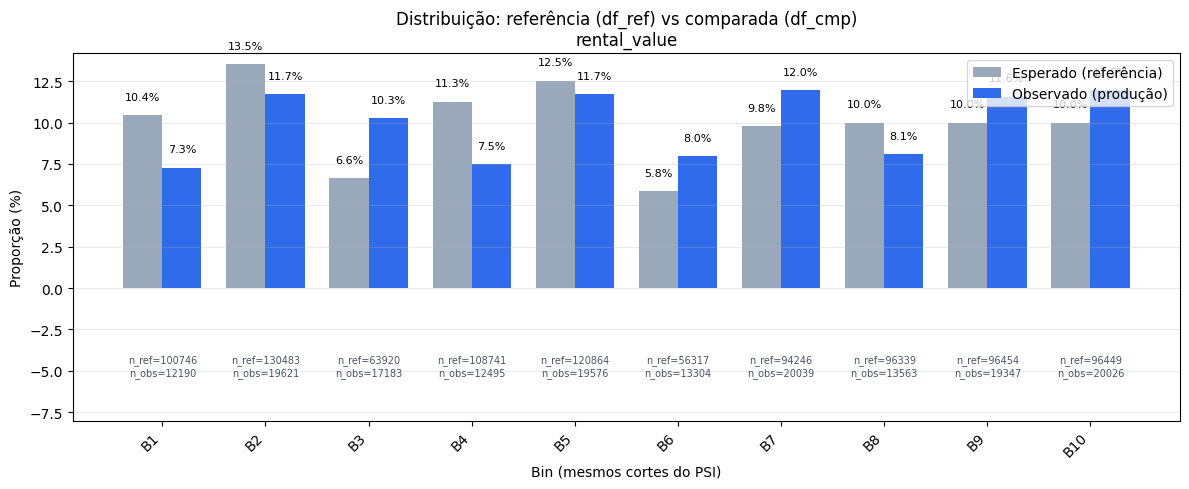

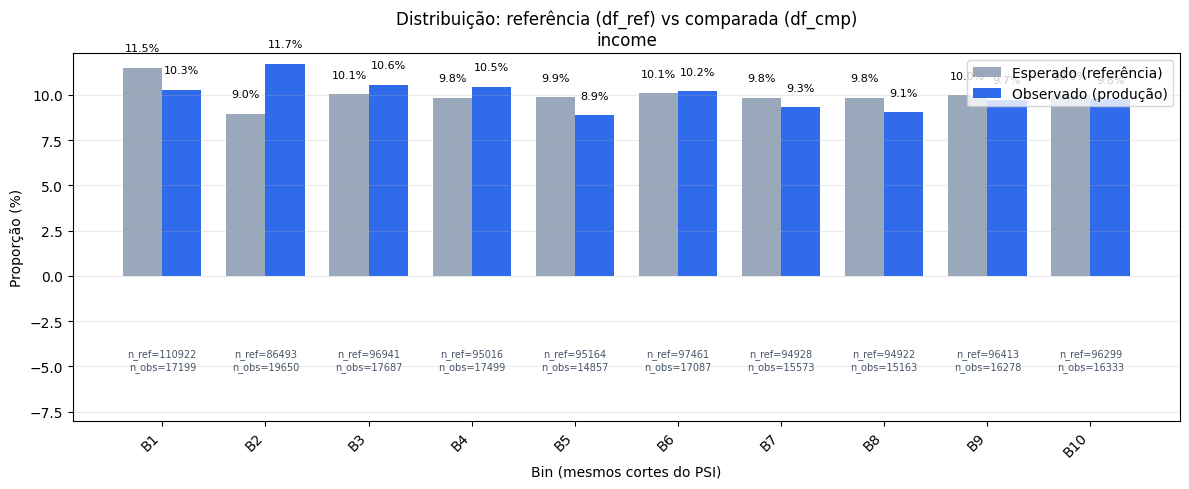

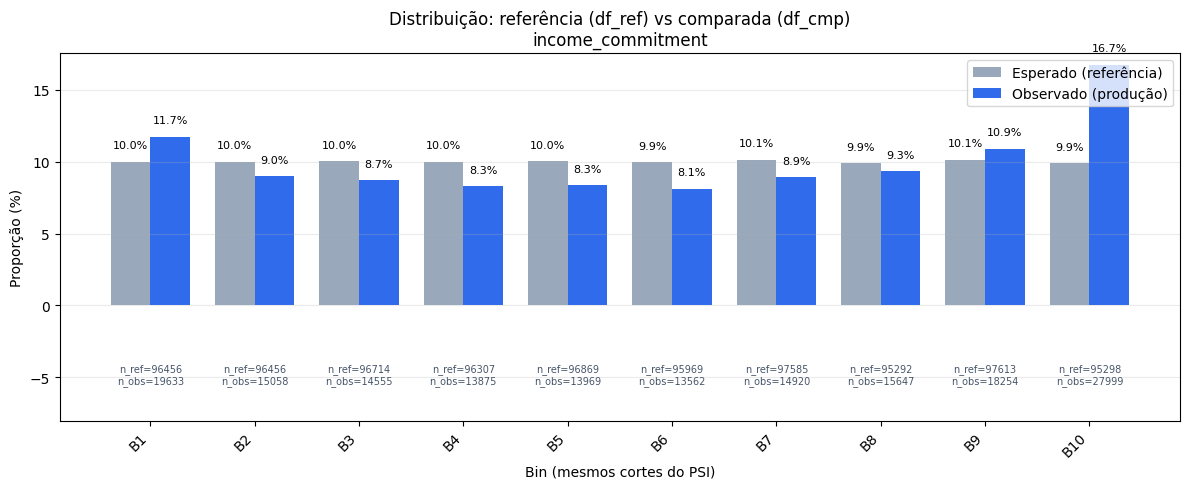

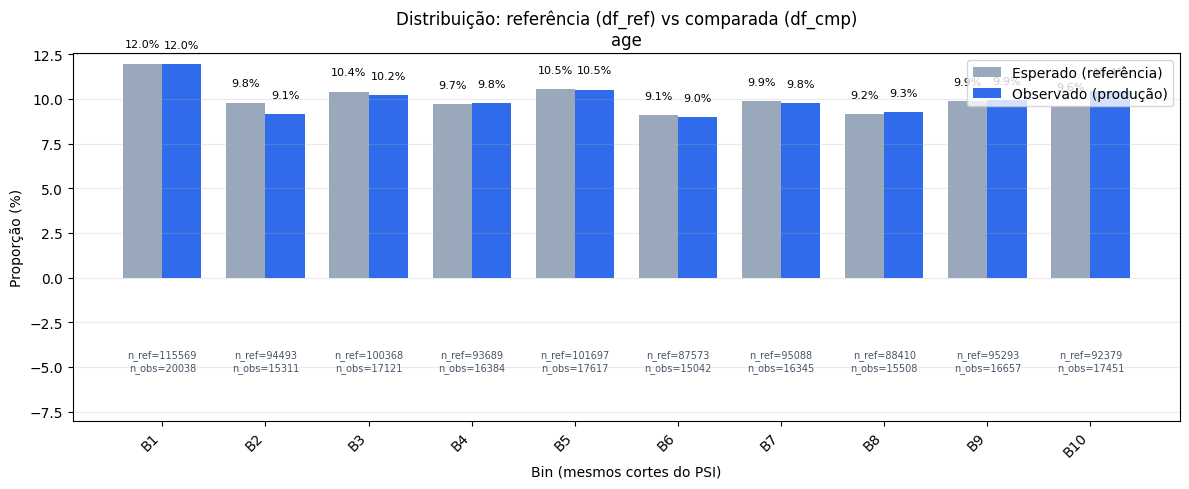

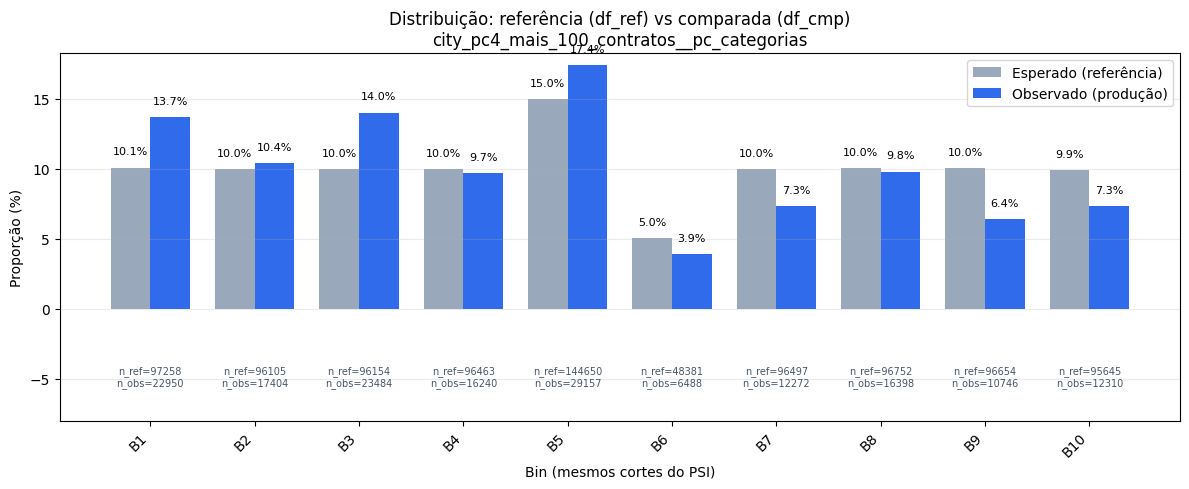

In [50]:
import pandas as pd
import numpy as np
from funcoes_escoragem import prepare_blend4_variables
from funcoes_psi import (
    build_psi_reference_artifact,
    build_distribution_comparison,
    calculate_psi_from_reference,
    plot_variable_distribution,
    plot_distribution_comparison,
)

VARS = ["rental_value", "income", "income_commitment", "age", "city_pc4_mais_100_contratos__pc_categorias"]
N_DECIS = 10

# 1) Garantir income_commitment nas duas bases
# Se df/df_predict ainda não passaram pelo prepare, faça:
# df_ref = prepare_blend4_variables(df.copy())
# df_cmp = prepare_blend4_variables(df_predict.copy())

df_ref = df_predict.copy()
df_cmp = df[df["income"] > 0].copy()

# Se income_commitment não existir:
for d in (df_ref, df_cmp):
    if "income_commitment" not in d.columns:
        d["income_commitment"] = d["rental_value"] / d["income"]
        d["income_commitment"] = d["income_commitment"].replace([np.inf, -np.inf], np.nan)

# 2) Criar deciles na referência e congelar os cortes
artifact = build_psi_reference_artifact(
    df_reference=df_ref,
    variables=VARS,
    n_bins=N_DECIS,
)

# 3) Ver min/max de cada decil (cortes congelados)
for var in VARS:
    spec = artifact["variables"][var]
    edges = spec["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")

# 4) Comparar distribuição referência vs comparada (mesmos cortes)
comparison_tables = {}
psi_rows = []

for var in VARS:
    spec = artifact["variables"][var]

    # Tabela por decil
    cmp_df = build_distribution_comparison(df_cmp[var], spec)
    cmp_df.insert(0, "variable", var)
    comparison_tables[var] = cmp_df

    # PSI resumindo o desvio total
    psi = calculate_psi_from_reference(df_cmp[var], spec)
    psi_rows.append({"variable": var, "psi": psi})

display(pd.concat(comparison_tables.values(), ignore_index=True))
display(pd.DataFrame(psi_rows))

# 5) Gráficos
for var in VARS:
    plot_variable_distribution(
        df_actual=df_cmp,
        artifact=artifact,
        variable=var,
        title="Distribuição: referência (df_ref) vs comparada (df_cmp)",
        show_counts=True,
    )

In [52]:
for var in ["rental_value", "income", "income_commitment", "city_pc4_mais_100_contratos__pc_categorias"]:
    edges = artifact["variables"][var]["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")


=== rental_value ===
Decil 01: (1.0500, 840.0000]
Decil 02: (840.0000, 1050.0000]
Decil 03: (1050.0000, 1207.5000]
Decil 04: (1207.5000, 1365.0000]
Decil 05: (1365.0000, 1575.0000]
Decil 06: (1575.0000, 1732.5000]
Decil 07: (1732.5000, 2016.0000]
Decil 08: (2016.0000, 2488.5000]
Decil 09: (2488.5000, 3265.5000]
Decil 10: (3265.5000, 20895.0000]

=== income ===
Decil 01: (479.5000, 1575.5000]
Decil 02: (1575.5000, 1849.5000]
Decil 03: (1849.5000, 2260.5000]
Decil 04: (2260.5000, 2877.0000]
Decil 05: (2877.0000, 3836.0000]
Decil 06: (3836.0000, 4589.5000]
Decil 07: (4589.5000, 5685.5000]
Decil 08: (5685.5000, 8014.5000]
Decil 09: (8014.5000, 13494.5000]
Decil 10: (13494.5000, 184881.5000]

=== income_commitment ===
Decil 01: (0.0000, 0.1274]
Decil 02: (0.1274, 0.2020]
Decil 03: (0.2020, 0.2705]
Decil 04: (0.2705, 0.3429]
Decil 05: (0.3429, 0.4229]
Decil 06: (0.4229, 0.5132]
Decil 07: (0.5132, 0.6271]
Decil 08: (0.6271, 0.7771]
Decil 09: (0.7771, 1.0451]
Decil 10: (1.0451, 15.6713]

=== 

In [53]:
df_ref[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
rental_value,964559.0,1924.498164,1449.515413,1.050000,840.000000,1050.000000,1207.500000,1365.000000,1575.000000,1732.500000,2016.000000,2488.500000,3265.500000,20895.000000
income,964559.0,7310.812823,13050.017738,479.500000,1575.500000,1849.500000,2260.500000,2877.000000,3836.000000,4589.500000,5685.500000,8014.500000,13494.500000,184881.500000
income_commitment,964559.0,0.536164,0.481497,0.000028,0.127450,0.202010,0.270502,0.342874,0.422854,0.513170,0.627074,0.777068,1.045123,15.671341
age,964559.0,37.758577,14.268551,0.000000,22.000000,25.000000,28.000000,31.000000,35.000000,39.000000,44.000000,50.000000,59.000000,89.000000
city_pc4_mais_100_contratos__pc_categorias,964559.0,0.109737,0.033855,0.009709,0.072218,0.083923,0.093514,0.101961,0.102330,0.107383,0.120307,0.135948,0.152318,0.270270


In [54]:
df_cmp[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
rental_value,167553.0,2620.598274,68190.125224,1.000000,900.000000,1100.000000,1250.000000,1400.000000,1600.00000,1800.000000,2150.000000,2600.000000,3500.000000,1.330849e+07
income,167557.0,7538.733080,15391.464989,479.500000,1507.000000,1849.500000,2192.000000,2671.500000,3630.50000,4452.500000,5548.500000,7809.000000,13357.500000,2.055000e+05
income_commitment,167557.0,0.784817,13.069692,0.000124,0.112157,0.196519,0.275444,0.364964,0.46603,0.583942,0.729927,0.948905,1.351717,2.988993e+03
age,167557.0,38.206670,14.656363,18.000000,22.000000,25.000000,28.000000,31.000000,35.00000,39.000000,44.000000,51.000000,60.000000,1.030000e+02
city_pc4_mais_100_contratos__pc_categorias,167557.0,0.102216,0.029703,0.007576,0.066168,0.076923,0.086642,0.095109,0.10233,0.102330,0.108791,0.125544,0.144144,2.377622e-01


In [33]:
100*(2620.598274/1924.498164 - 1)

36.170474101839666

In [34]:
100*(7538.733080/7310.812823 - 1)

3.1175775186441212

In [35]:
df_cmp["income"].describe()

count    167557.000000
mean       7538.733080
std       15391.464989
min         479.500000
25%        1986.500000
50%        3630.500000
75%        6439.000000
max      205500.000000
Name: income, dtype: float64

## Variável: city_pc4_mais_100_contratos__pc_categorias

In [55]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1323,2026-06-01,4303103,0.177215
1324,2026-06-01,2933307,0.178694
1325,2026-06-01,2800308,0.192534
1326,2026-06-01,3533908,0.192810


In [63]:
df_ref[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
city_pc4_mais_100_contratos__pc_categorias,964559.0,0.109737,0.033855,0.009709,0.072218,0.083923,0.093514,0.101961,0.10233,0.107383,0.120307,0.135948,0.152318,0.27027


In [58]:
df_cmp[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
city_pc4_mais_100_contratos__pc_categorias,167557.0,0.102216,0.029703,0.007576,0.066168,0.076923,0.086642,0.095109,0.10233,0.10233,0.108791,0.125544,0.144144,0.237762


In [62]:
var = "city_pc4_mais_100_contratos__pc_categorias"
percentiles = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

summary = (
    df_city.groupby("mes_referencia")[var]
    .describe(percentiles=percentiles)
    .round(4)
)

display(summary)

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
mes_referencia,,,,,,,,,,,,,,
2025-12-01,182.0,0.1140,0.0439,0.0281,0.0587,0.0780,0.0883,0.0981,0.1107,0.1214,0.1345,0.1470,0.1684,0.2535
2026-01-01,186.0,0.1104,0.0435,0.0096,0.0596,0.0745,0.0825,0.0973,0.1067,0.1150,0.1315,0.1462,0.1652,0.2468
2026-02-01,188.0,0.1058,0.0438,0.0156,0.0589,0.0701,0.0794,0.0907,0.1020,0.1139,0.1253,0.1434,0.1587,0.2774
2026-03-01,191.0,0.1001,0.0428,0.0066,0.0552,0.0672,0.0747,0.0853,0.0943,0.1063,0.1209,0.1361,0.1553,0.2568
2026-04-01,194.0,0.0968,0.0406,0.0136,0.0512,0.0647,0.0719,0.0830,0.0919,0.1036,0.1152,0.1274,0.1504,0.2671
2026-05-01,192.0,0.0954,0.0379,0.0145,0.0516,0.0635,0.0735,0.0836,0.0900,0.0979,0.1122,0.1246,0.1459,0.2378
2026-06-01,195.0,0.0948,0.0376,0.0076,0.0509,0.0634,0.0730,0.0794,0.0907,0.0977,0.1117,0.1270,0.1458,0.2270


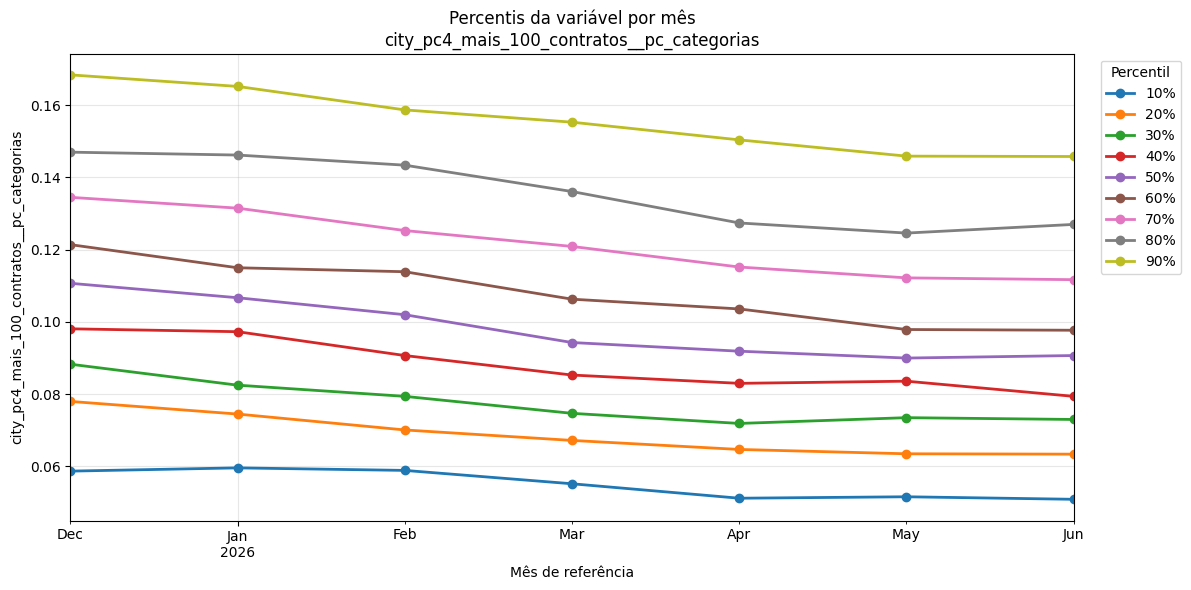

In [64]:
percentile_cols = [f"{p}%" for p in range(10, 100, 10)]  # ['10%', '20%', ..., '90%']

plot_df = summary[percentile_cols].copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

ax = plot_df.plot(
    figsize=(12, 6),
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Mês de referência")
ax.set_ylabel(var)
ax.set_title(f"Percentis da variável por mês\n{var}")
ax.grid(alpha=0.3)
ax.legend(title="Percentil", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()